In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df=pd.read_csv('C:/Users/Haseeb/Downloads/Developers Hub/Datasets/Task 2/loan_prediction.csv')

In [3]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df=df.drop('LoanID',axis=1)

In [6]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
df['Education'] = df['Education'].map({
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'PhD': 3
})

df['EmploymentType'] = df['EmploymentType'].map({
    'Unemployed': 0,
    'Self-employed': 1,
    'Part-time': 2,
    'Full-time': 3
})

df['MaritalStatus'] = df['MaritalStatus'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})

df['HasMortgage'] = df['HasMortgage'].map({'No': 0, 'Yes': 1})
df['HasDependents'] = df['HasDependents'].map({'No': 0, 'Yes': 1})
df['HasCoSigner'] = df['HasCoSigner'].map({'No': 0, 'Yes': 1})

df['LoanPurpose'] = df['LoanPurpose'].map({
    'Other': 0,
    'Auto': 1,
    'Business': 2,
    'Home': 3,
    'Education': 4
})

In [8]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,1,3,2,1,1,0,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,3,1,0,0,0,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,0,2,1,1,1,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,0,3,1,0,0,2,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,1,0,2,0,1,1,0,0


In [9]:
df.isnull().sum()

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [10]:
print(df['Education'].unique())

[1 2 0 3]


In [11]:
df['Education'].isnull().sum()


np.int64(0)

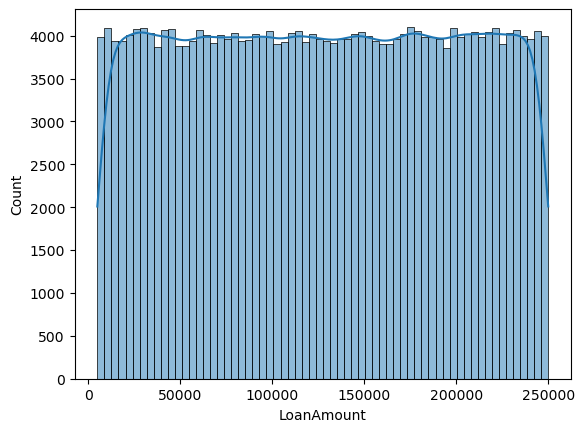

In [12]:
sns.histplot(df['LoanAmount'], kde=True)
plt.show()

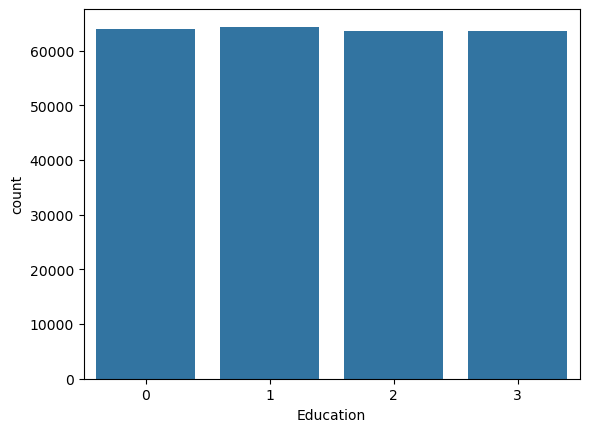

In [29]:
sns.countplot(x=df['Education'])
plt.show()

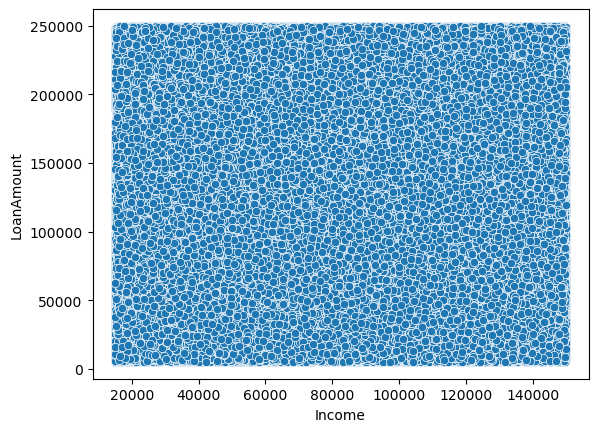

In [14]:
sns.scatterplot(x=df['Income'], y=df['LoanAmount'])
plt.show()

In [30]:
print(df['Default'].value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


In [32]:
from sklearn.utils import resample


In [35]:
majority = df[df['Default'] == 0]
minority = df[df['Default'] == 1]

In [36]:
majority_downsampled = resample(majority,
                                replace=False,
                                n_samples=len(minority),
                                random_state=42)

In [38]:
df_balanced = pd.concat([majority_downsampled, minority])

In [40]:
print(df_balanced['Default'].value_counts())

Default
0    29653
1    29653
Name: count, dtype: int64


In [41]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

In [58]:
X=df_balanced[['Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']]
y=df_balanced['Default']

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
from sklearn.model_selection import train_test_split 

In [61]:
from sklearn.linear_model import LogisticRegression 

In [62]:
model = LogisticRegression(max_iter=100)

In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
X_train = scaler.fit_transform(X_train)

In [67]:
X_test = scaler.transform(X_test)

In [68]:
model.fit(X_train, y_train)

LogisticRegression()

In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6834429269937616
Confusion Matrix:
 [[3969 1900]
 [1855 4138]]
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68      5869
           1       0.69      0.69      0.69      5993

    accuracy                           0.68     11862
   macro avg       0.68      0.68      0.68     11862
weighted avg       0.68      0.68      0.68     11862

